In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

In [2]:
TEMP = 23 #celcius
HUMIDITY = 61 #%
PRESSURE = 992e2 / 133.322387415 #mmhg
DENSITY = (0.46455 * PRESSURE - HUMIDITY * (0.00252 * TEMP - 0.020582)) / (TEMP + 273.15) #kg/m3
print(DENSITY)

H_ATM = 136
H_PITOT = 14.65
CORDLENGTH = 150

plot_configs = [
    ('0', 0, 'indianred'),
    ('6', 6, 'steelblue'),
    ('m4', -4, 'lightseagreen')
]

1.1594581064279144


In [3]:
df = pd.read_csv('downstream.csv')

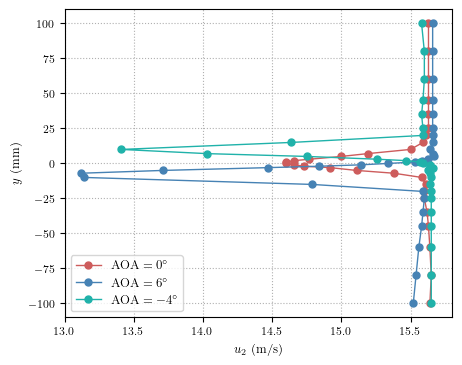

    loc   aoa0   aoa6  aoam4       dp0    u20       dp6    u26      dpm4  \
0   100  14.44  14.50  14.34  141.6564  15.63  142.2450  15.66  140.6754   
1    80  14.44  14.50  14.39  141.6564  15.63  142.2450  15.66  141.1659   
2    60  14.44  14.50  14.38  141.6564  15.63  142.2450  15.66  141.0678   
3    45  14.44  14.50  14.36  141.6564  15.63  142.2450  15.66  140.8716   
4    35  14.44  14.50  14.35  141.6564  15.63  142.2450  15.66  140.7735   
5    25  14.44  14.50  14.37  141.6564  15.63  142.2450  15.66  140.9697   
6    20  14.40  14.50  14.36  141.2640  15.61  142.2450  15.66  140.8716   
7    15  14.37  14.50  12.67  140.9697  15.59  142.2450  15.66  124.2927   
8    10  14.20  14.46  10.63  139.3020  15.50  141.8526  15.64  104.2803   
9     7  13.63  14.49  11.64  133.7103  15.19  142.1469  15.66  114.1884   
10    5  13.30  14.51  12.85  130.4730  15.00  142.3431  15.67  126.0585   
11    3  12.90  14.43  13.76  126.5490  14.77  141.5583  15.63  134.9856   
12    2  12.

In [25]:
fig, ax = plt.subplots(figsize=(5,4))

for suffix, aoa_val, color in plot_configs:
    df[f'u2{suffix}'] = np.sqrt(2 * df[f'dp{suffix}'] / DENSITY).round(2)

    ax.plot(df[f'u2{suffix}'], df['loc'],
            label=fr'$\mathrm{{AOA}}={aoa_val}^\circ$', marker='o', color=color, markersize=5, lw=1)

df[['loc', 'u20', 'u26', 'u2m4']].to_csv('u2.csv', index=False)

ax.set_xlabel('$u_2$ (m/s)')
ax.set_xlim(13.0, 15.8)
ax.set_ylabel('$y$ (mm)')
ax.legend(loc='lower left')
ax.grid(True, linestyle=':')

fig.savefig('u2.pdf', format='pdf', bbox_inches='tight')
plt.show()

print(df)

In [20]:
drag = {}
drag_coeff = {}

for suffix, aoa_val, color in plot_configs:
    u_array = df[f'u2{suffix}'].values
    y_array = df['loc'].values * 0.001
    
    u1 = np.max(u_array)
    print(f"dP(AOA_{aoa_val}) = {u1}Pa")
    d_prime = 0
    
    for i in range(len(y_array) - 1):
        dy = y_array[i] - y_array[i+1]
        u2_avg = (u_array[i] + u_array[i+1]) / 2
        d_prime += DENSITY * u2_avg * (u1 - u2_avg) * dy
    drag[f'AOA_{aoa_val}'] = d_prime
    drag_coeff[f'AOA_{aoa_val}'] = 2 * d_prime / (DENSITY * 15.74**2 * CORDLENGTH * 0.001) 

for k, v in drag.items():
    print(f"D'({k}) = {v:.4f} N/m")

for k, v in drag_coeff.items():
    print(f"Cd({k}) = {v:.4f}")

dP(AOA_0) = 15.647906283289057Pa
dP(AOA_6) = 15.669519423815636Pa
dP(AOA_-4) = 15.664118934451784Pa
D'(AOA_0) = 0.2731 N/m
D'(AOA_6) = 0.6293 N/m
D'(AOA_-4) = 0.4748 N/m
Cd(AOA_0) = 0.0127
Cd(AOA_6) = 0.0292
Cd(AOA_-4) = 0.0220
